In [11]:
# Import Packages & Libraries
import json
import numpy as np
import pandas as pd
import nltk
from bs4 import BeautifulSoup

first_name = "Benjamin"
last_name = "Branta"

In [2]:
# Task 1 Scrabble
# Subtask 1.1 - Import files to dictionaries
with (
    open("english_letter_scores.json", "r") as english_letter_scrores_file,
    open("german_letter_scores.json", "r") as german_letter_scrores_file,
):
    english_letter_scores = json.load(english_letter_scrores_file)
    german_letter_scores = json.load(german_letter_scrores_file)

In [3]:
# Write a function word_score that has two args (str and score dict)
# and returns the score of that string.
def word_score(word: str, score_dict: dict) -> int | None:
    score = 0
    all_letters = {letter for values in score_dict.values() for letter in values}
    for letter in word.upper():  # get character to check
        if letter not in all_letters:
            return np.nan
        else:
            for key, values in score_dict.items():
                if letter in values:
                    score += int(key)
    return score

#word_score("FOX",english_letter_scores)
#word_score("FOX",german_letter_scores) == 14
#np.isnan(word_score("FÖX",english_letter_scores)) == True

In [4]:
# Subtask 1.2
def non_alpha_non_space_chars(s: str) -> set:
    non_alpha_non_space_set = set()
    for char in s:
        if not char.isalpha() and not char.isspace():
            non_alpha_non_space_set.add(char)
    return non_alpha_non_space_set


def clean(s: str) -> str:
    non_alpha_non_space = non_alpha_non_space_chars(s)
    cleaned_string = ""
    for char in s:  # for each character in string
        if char not in non_alpha_non_space:
            cleaned_string += char.lower()  # add to cleaned string as lower case.
    return cleaned_string


def read_and_clean(filename: str) -> str:
    with open(filename, "r", encoding="utf-8") as file:  # open file as read
        text = file.read()  # read file and save text
    return clean(text)  # return the cleaned string


def word_counts(s: str) -> dict:
    cleaned_string = clean(s)  # clean the string
    words = cleaned_string.split()  # split on whitespace char
    counts = {}  # create an empty dictionary
    for word in words:  # for each word in words
        if word in counts:  # if key exists in counts dict
            counts[word] += 1  # inrement the value by 1
        else:  # if key does not exist
            counts[word] = 1  # creates the key value pair and sets value to 1
    return counts


def word_counts_from_file(filename: str) -> pd.DataFrame:
    cleaned_text = read_and_clean(filename)
    word_counts_dict = word_counts(cleaned_text)
    word_counts_df = pd.DataFrame(
        word_counts_dict.items(),
        columns=["Word", "Count"]
    )
    return word_counts_df

def add_score_column(df: pd.DataFrame, score_dict: dict, new_column_name: str) -> None:
    df[new_column_name] = df["Word"].apply(lambda row: word_score(row, score_dict))
    return None


In [5]:
# Subtask 1.3 - Score Data
def score_data(df: pd.DataFrame, count_column: str, score_column: str, ignored_words: list = []):
    scored = df.dropna(subset=[score_column])  # exclude words without a score
    scored = scored[~scored["Word"].isin(ignored_words)]  # exclude ignored words
    total_score = (scored[count_column] * scored[score_column]).sum()
    avg_score_per_word = total_score / scored[count_column].sum()
    median_word_score = np.median(scored[score_column].repeat(scored[count_column].tolist()).tolist())
    return (total_score, avg_score_per_word, median_word_score)


df = word_counts_from_file("example_text.txt")
add_score_column(df,english_letter_scores,"English Score")
add_score_column(df,german_letter_scores,"German Score")
# assert score_data(df,"Count","English Score") == (319, 6.018867924528302, 7.0)
# assert score_data(df,"Count","German Score") == (312.0, 5.886792452830188, 5.0)

stopwords_english = nltk.corpus.stopwords.words('english')
stopwords_german = nltk.corpus.stopwords.words('german')
assert score_data(df,"Count","English Score",stopwords_english) == (193.0, 9.19047619047619, 10.0)
assert score_data(df,"Count","German Score",stopwords_german) == (307.0, 6.019607843137255, 5.0)

In [6]:
# Task 2 - Sentiment Analysis
# Subtask 2.1 - Getting Wiki Page Content
import requests

def wikipedia_page_content(title: str) -> str:
    response = requests.get(
        "https://en.wikipedia.org/w/api.php",
        params={
            "action": "query",
            "prop": "extracts",
            "explaintext": True,
            "titles": title,
            "format": "json",
        },
        headers={"User-Agent": "DS710-Assignment8/1.0 (bbranta15@gmail.com)"},
    )
    response.raise_for_status()
    pages = response.json()["query"]["pages"]
    page = next(iter(pages.values()))
    return page.get("extract", "")


assert (
    wikipedia_page_content("Carla Cotwright-Williams")[:292]
    == "Carla Denise Cotwright-Williams is an American mathematician who works as a Technical Director and Data Scientist for the United States Department of Defense. She was the second African-American woman to earn a doctorate in mathematics at the University of Mississippi.\n\n\n== Early life and ed"
)


In [ ]:
# Subtask 2.2 - Selecting a target for sentiment analysis
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/List_of_primary_Interstate_Highways"
response = requests.get(url, headers={"User-Agent": "DS710-Assignment8/1.0 (brantabe53@uwosh.edu)"})
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")
tables = soup.find_all("table", {"class": "wikitable"})  # mainland, Hawaii, Alaska, Puerto Rico

titles = []
lengths = []
formed = []

for table in tables:
    for row in table.find_all("tr")[1:]:  # skip header row
        cells = row.find_all(["td", "th"])
        if len(cells) < 6:
            continue

        # the link's title attribute has the full page name, e.g. "Interstate 88 (New York)"
        link = cells[0].find("a")
        titles.append(link.get("title") if link else cells[0].get_text(strip=True))

        length_text = cells[1].get_text(strip=True).replace(",", "")
        try:
            lengths.append(float(length_text))
        except ValueError:  # no length listed, e.g. "—" for unbuilt routes
            lengths.append(np.nan)

        formed_cell = cells[5]
        for span in formed_cell.find_all("span"):
            style = span.get("style", "")
            if "display:none" in style.replace(" ", ""):
                span.decompose()  # drop the hidden Wikipedia sort-key text
        formed.append(formed_cell.get_text(strip=True))

interstate_df = pd.DataFrame({
    "Title": titles,
    "Length(mi)": lengths,
    "Formed": formed,
})

interstate_df["Page Contents"] = interstate_df["Title"].apply(wikipedia_page_content)


In [ ]:
# Subtask 2.3 - Sentiment Analysis

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize

# one-time downloads of the tokenizer data, stopword list, and VADER lexicon
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("vader_lexicon")

stopwords_english = stopwords.words("english")
sia = SentimentIntensityAnalyzer()


def sentiment_scores(text: str) -> dict:
    tokens = word_tokenize(text.lower())
    filtered_tokens = [token for token in tokens if token not in stopwords_english]
    filtered_text = " ".join(filtered_tokens)  # rejoin so we score a string, not a list
    return sia.polarity_scores(filtered_text)


scores = interstate_df["Page Contents"].apply(sentiment_scores)
interstate_df["neg"] = scores.apply(lambda s: s["neg"])
interstate_df["neu"] = scores.apply(lambda s: s["neu"])
interstate_df["pos"] = scores.apply(lambda s: s["pos"])
interstate_df["compound"] = scores.apply(lambda s: s["compound"])


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\benbr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\benbr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\benbr\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


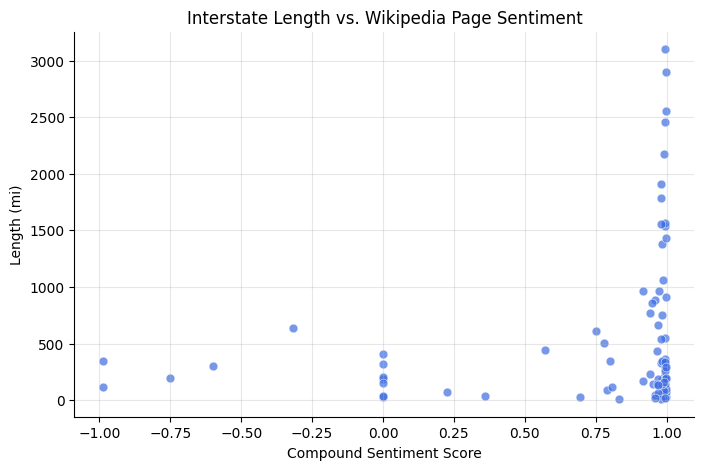

In [12]:
# Subtask 2.4
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    interstate_df["compound"],
    interstate_df["Length(mi)"],
    s=40,
    color="#3d6ce0",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
)

ax.set_xlabel("Compound Sentiment Score")
ax.set_ylabel("Length (mi)")
ax.set_title("Interstate Length vs. Wikipedia Page Sentiment")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, alpha=0.3)

fig.savefig(f"{last_name}_{first_name}_assign8_task2-4.png", dpi=150, bbox_inches="tight")
plt.show()


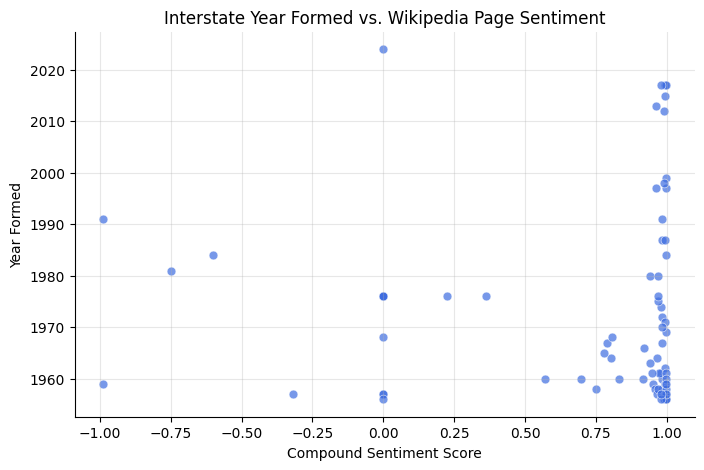

In [ ]:
# Subtask 2.5 - Sentiment vs Year Formed
formed_year = pd.to_numeric(interstate_df["Formed"].str[:4], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    interstate_df["compound"],
    formed_year,
    s=40,
    color="#3d6ce0",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
)

ax.set_xlabel("Compound Sentiment Score")
ax.set_ylabel("Year Formed")
ax.set_title("Interstate Year Formed vs. Wikipedia Page Sentiment")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, alpha=0.3)

fig.savefig(f"{last_name}_{first_name}_assign8_task2-5.png", dpi=150, bbox_inches="tight")
plt.show()


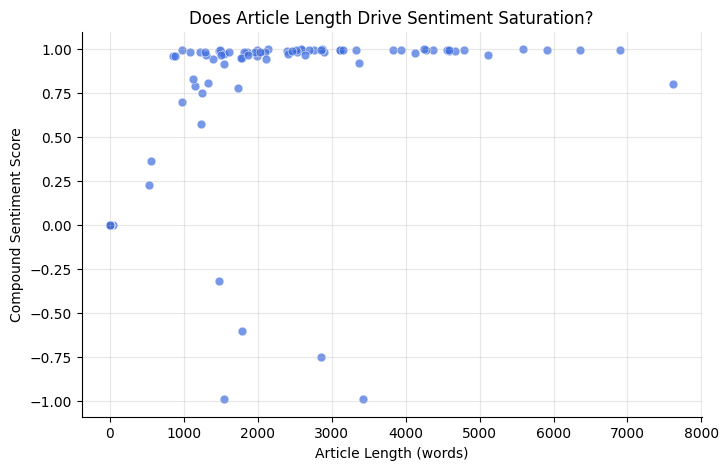

In [14]:
word_count = interstate_df["Page Contents"].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    word_count,
    interstate_df["compound"],
    s=40,
    color="#3d6ce0",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
)
ax.set_xlabel("Article Length (words)")
ax.set_ylabel("Compound Sentiment Score")
ax.set_title("Does Article Length Drive Sentiment Saturation?")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, alpha=0.3)
fig.savefig(f"{last_name}_{first_name}_assign8_task2-6-1.png", dpi=150, bbox_inches="tight")
plt.show()


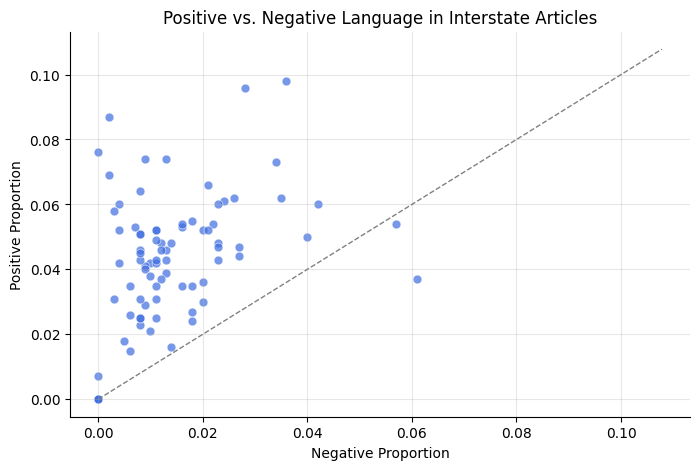

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    interstate_df["neg"],
    interstate_df["pos"],
    s=40,
    color="#3d6ce0",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
)
max_val = max(interstate_df["neg"].max(), interstate_df["pos"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], color="gray", linewidth=1, linestyle="--")  # pos == neg reference
ax.set_xlabel("Negative Proportion")
ax.set_ylabel("Positive Proportion")
ax.set_title("Positive vs. Negative Language in Interstate Articles")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, alpha=0.3)
fig.savefig(f"{last_name}_{first_name}_assign8_task2-6-2.png", dpi=150, bbox_inches="tight")
plt.show()


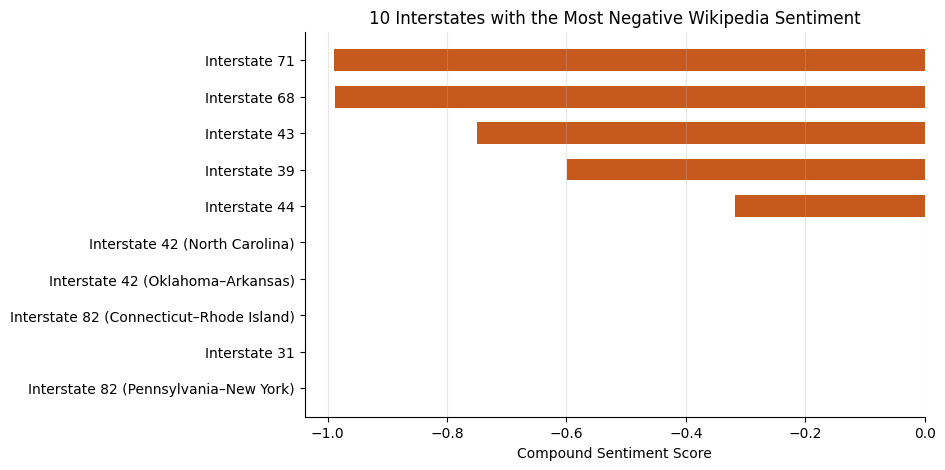

In [16]:
most_negative = interstate_df.nsmallest(10, "compound").sort_values("compound", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    most_negative["Title"],
    most_negative["compound"],
    color="#c65a1e",
    height=0.6,
)
ax.set_xlabel("Compound Sentiment Score")
ax.set_title("10 Interstates with the Most Negative Wikipedia Sentiment")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="x", alpha=0.3)
fig.savefig(f"{last_name}_{first_name}_assign8_task2-6-3.png", dpi=150, bbox_inches="tight")
plt.show()
